# Smoke Test — OOD Probe Transfer Experiment

**Goal of this notebook:** verify the entire experimental pipeline works end-to-end on a tiny scale before we spend money on bigger GPUs.

Everything below should run on a free Colab T4 in roughly 3–5 minutes. If every cell completes without errors and the final AUC table looks reasonable, we know the full experiment will work.

**Before you start:** click `Runtime` → `Change runtime type` → set Hardware accelerator to `T4 GPU` → Save. If you don't do this, the script will fall back to CPU and take 30+ minutes.

## Cell 1 — Install dependencies

Colab comes with PyTorch preinstalled but not with the latest `transformers` or `datasets`, so we update them. The `-q` flag just makes pip quieter.

In [ ]:
!pip install -q -U transformers datasets accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.3 MB/s eta 0:00:00


## Cell 2 — Imports and config

All the knobs you'd want to change are at the top of this cell. For the smoke test we use:
- `Qwen2.5-1.5B-Instruct` — tiny model that fits comfortably on Colab's T4 (16 GB VRAM).
- 50 problems — enough to give the probe some signal but small enough to finish in minutes.
- 512 max new tokens — plenty for GSM8K which usually needs ~200.

After running this cell you should see `Device: cuda`. If it says `cpu`, your runtime is not on GPU and you need to change it (see top of notebook).

In [ ]:
import os, re, json
from pathlib import Path

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# ---- Knobs ----
MODEL_NAME     = "Qwen/Qwen2.5-1.5B-Instruct"
NUM_SAMPLES    = 50
MAX_NEW_TOKENS = 512
SEED           = 42
OUTPUT_DIR     = Path("smoke_test_outputs")
# ---------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Dtype:  {DTYPE}")
if DEVICE == "cpu":
    print("WARNING: no GPU detected. Go to Runtime > Change runtime type > T4 GPU.")

Device: cuda
Dtype:  torch.float16


## Cell 3 — Load the model

This downloads ~3 GB of weights the first time and then caches them. On Colab the cache survives until the runtime disconnects, so the second run is much faster.

`model.eval()` disables dropout, which we want during inference.

In [ ]:
print(f"Loading {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map=DEVICE,
)
model.eval()

NUM_LAYERS = model.config.num_hidden_layers
HIDDEN_DIM = model.config.hidden_size
print(f"Loaded.  num_layers={NUM_LAYERS}  hidden_dim={HIDDEN_DIM}")

Loading Qwen/Qwen2.5-1.5B-Instruct ...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded.  num_layers=28  hidden_dim=1536


## Cell 4 — Load the dataset

GSM8K is a grade-school math word-problem benchmark. We use the test split (the train split was likely in the model's pretraining data, which would inflate accuracy).

Each row has a `question` and an `answer`. The answer is a worked solution ending in `#### N` where `N` is the final number.

In [ ]:
ds = load_dataset("openai/gsm8k", "main", split=f"test[:{NUM_SAMPLES}]")
print(f"Loaded {len(ds)} problems")
print("\nFirst problem:")
print("Q:", ds[0]["question"])
print("\nA:", ds[0]["answer"])

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Loaded 50 problems

First problem:
Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

A: Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.
#### 18


## Cell 5 — Helper functions

Three small utilities:

- `format_prompt` wraps the question in the model's chat template and adds an instruction to end with `The answer is X.`
- `parse_gsm8k_gold` extracts the ground-truth number from the `#### N` line
- `extract_predicted_answer` tries several regex patterns to pull a number out of the model's free-form text. This is the most fragile part of the pipeline; for the real experiment we'll need a more robust answer-extractor for each dataset.

In [ ]:
def format_prompt(question: str) -> str:
    messages = [
        {"role": "user",
         "content": (f"Solve the following problem step by step. "
                     f"End your answer with the line: 'The answer is X.'\n\n{question}")}
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

def parse_gsm8k_gold(answer_text: str):
    m = re.search(r"####\s*(-?\d+(?:\.\d+)?)", answer_text)
    return float(m.group(1)) if m else None

def extract_predicted_answer(text: str):
    patterns = [
        r"answer is[:\s]*\$?(-?[\d,]+(?:\.\d+)?)",
        r"\\boxed\{(-?[\d,]+(?:\.\d+)?)\}",
        r"=\s*\$?(-?[\d,]+(?:\.\d+)?)\s*\.?\s*$",
    ]
    for pat in patterns:
        m = re.search(pat, text, re.IGNORECASE | re.MULTILINE)
        if m:
            try:
                return float(m.group(1).replace(",", ""))
            except ValueError:
                continue
    return None

# Quick test of the helpers
print("Sample formatted prompt:")
print(format_prompt("What is 2 + 2?")[:300], "...")

Sample formatted prompt:
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Solve the following problem step by step. End your answer with the line: 'The answer is X.'

What is 2 + 2?<|im_end|>
<|im_start|>assistant
 ...


## Cell 6 — Stage 1: generate rollouts and collect hidden states

This is the part that needs the GPU. For each of the 50 problems we:

1. Generate a chain-of-thought + final answer with greedy decoding
2. Grab the residual-stream activations from the LAST generation step
3. Label correct/incorrect by comparing the predicted number to ground truth

The critical flag is `output_hidden_states=True` — that's what makes the model record activations at every layer. Without it, this would just be a benchmark script.

Progress will print every 10 problems. Expect total runtime around 2–4 minutes on a T4.

In [ ]:
all_hidden_states = []   # one [num_layers+1, hidden_dim] array per problem
all_labels        = []   # 0/1 per problem
all_diagnostics   = []   # debug info per problem

for i, row in enumerate(ds):
    question  = row["question"]
    gt_answer = parse_gsm8k_gold(row["answer"])

    prompt = format_prompt(question)
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            return_dict_in_generate=True,
            output_hidden_states=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode just the generated portion (skip prompt tokens)
    gen_ids  = outputs.sequences[0][inputs.input_ids.shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)

    # outputs.hidden_states is a tuple of length = num_generation_steps
    # Each entry is a tuple of length = num_layers+1 (embedding + each layer)
    # Each tensor: [batch, seq_len, hidden_dim]  (seq_len=1 for steps > 0)
    # We take the LAST step's per-layer activations (state after final answer token)
    last_step = outputs.hidden_states[-1]
    per_layer = torch.stack(
        [h[0, -1, :].cpu().float() for h in last_step],
    )

    # Correctness label
    pred_answer = extract_predicted_answer(gen_text)
    if pred_answer is not None and gt_answer is not None:
        label = int(abs(pred_answer - gt_answer) < 1e-4)
    else:
        label = 0

    all_hidden_states.append(per_layer.numpy())
    all_labels.append(label)
    all_diagnostics.append({
        "idx": i, "pred": pred_answer, "gt": gt_answer,
        "label": label, "tail_text": gen_text[-200:],
    })

    if (i + 1) % 10 == 0 or (i + 1) == NUM_SAMPLES:
        acc = sum(all_labels) / len(all_labels)
        print(f"  [{i+1:>3}/{NUM_SAMPLES}]  running accuracy: {acc:.1%}")

# Save artifacts
H = np.stack(all_hidden_states)
y = np.array(all_labels, dtype=np.int64)
np.savez(OUTPUT_DIR / "stage1_gsm8k_smoke.npz", hidden_states=H, labels=y)
with open(OUTPUT_DIR / "stage1_gsm8k_diagnostics.json", "w") as f:
    json.dump(all_diagnostics, f, indent=2)

print(f"\nFinal accuracy: {y.mean():.1%}   ({y.sum()} correct of {len(y)})")
print(f"Hidden states shape: {H.shape}   (problems, layers, dim)")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  [ 10/50]  running accuracy: 60.0%
  [ 20/50]  running accuracy: 50.0%
  [ 30/50]  running accuracy: 63.3%
  [ 40/50]  running accuracy: 70.0%
  [ 50/50]  running accuracy: 70.0%

Final accuracy: 70.0%   (35 correct of 50)
Hidden states shape: (50, 29, 1536)   (problems, layers, dim)


## Cell 7 — Eyeball a few examples

Always sanity-check the actual generations before trusting the labels. We print 3 correct and 3 incorrect cases so you can verify that the answer extractor and the labels are sensible. If labels look wrong here, the rest of the pipeline is garbage in / garbage out.

In [ ]:
correct_examples   = [d for d in all_diagnostics if d['label'] == 1][:3]
incorrect_examples = [d for d in all_diagnostics if d['label'] == 0][:3]

print("=== CORRECT examples ===")
for d in correct_examples:
    print(f"\n[idx={d['idx']}]  pred={d['pred']}  gt={d['gt']}")
    print(f"  tail: ...{d['tail_text']}")

print("\n=== INCORRECT examples ===")
for d in incorrect_examples:
    print(f"\n[idx={d['idx']}]  pred={d['pred']}  gt={d['gt']}")
    print(f"  tail: ...{d['tail_text']}")

=== CORRECT examples ===

[idx=0]  pred=18.0  gt=18.0
  tail: ...ng the eggs at the farmers' market**:
   \[
   9 \text{ eggs} \times \$2/\text{egg} = \$18/\text{day}
   \]

Therefore, the amount Janet makes every day at the farmers' market is $\boxed{18}$ dollars.

[idx=1]  pred=3.0  gt=3.0
  tail: ...al bolts} = \text{Blue fiber} + \text{White fiber} = 2 \text{ bolts} + 1 \text{ bolt} = 3 \text{ bolts}
   \]

Therefore, the total number of bolts of fiber needed for one robe is 3.

The answer is 3.

[idx=2]  pred=70000.0  gt=70000.0
  tail: ...selling the house:**
   - Subtract the total cost from the new value of the house.

   \[
   \text{Profit} = \$200,000 - \$130,000 = \$70,000
   \]

Therefore, the profit Josh made is $\boxed{70000}$.

=== INCORRECT examples ===

[idx=5]  pred=3.0  gt=64.0
  tail: ...
- Cost of the second pair:
  \[
  5 + 3 = 8
  \]
- And so on...

Since there are 8 such pairs, the total cost will be:
\[
8 \times 8 = 64
\]

Therefore, Kylar needs to pay **$64** 

## Cell 8 — Stage 3: train one linear probe per layer

Now we leave the LLM behind entirely. The saved activations are just an array of vectors with 0/1 labels. We train one logistic regression per layer and see which layer best predicts correctness.

**What to expect on a healthy run:** the best layer (usually somewhere in the middle-to-late layers) should land at AUC between 0.60 and 0.80. If every layer is around 0.50, the probe is finding no signal — which usually means too few examples, broken labels, or a model that's too weak.

In [ ]:
if y.sum() < 3 or (1 - y).sum() < 3:
    print(f"!! Not enough class diversity ({y.sum()} correct, {(1-y).sum()} wrong).")
    print(f"!! Try increasing NUM_SAMPLES or use a different model.")
else:
    per_layer_auc = []
    for layer in range(H.shape[1]):
        X = H[:, layer, :]
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.3, random_state=SEED, stratify=y,
        )
        clf = LogisticRegression(max_iter=2000, C=1.0)
        clf.fit(X_tr, y_tr)
        if len(np.unique(y_te)) == 2:
            probs = clf.predict_proba(X_te)[:, 1]
            auc = roc_auc_score(y_te, probs)
        else:
            auc = float("nan")
        per_layer_auc.append(auc)

    best = int(np.nanargmax(per_layer_auc))
    print("Layer | AUC")
    print("------+------")
    for layer, auc in enumerate(per_layer_auc):
        flag = " <-- best" if layer == best else ""
        print(f"{layer:>5} | {auc:.3f}{flag}")
    print(f"\nBest layer {best} with AUC {per_layer_auc[best]:.3f}")

Layer | AUC
------+------
    0 | 0.400
    1 | 0.840
    2 | 0.800
    3 | 0.840
    4 | 0.860
    5 | 0.860
    6 | 0.860
    7 | 0.880
    8 | 0.840
    9 | 0.840
   10 | 0.860
   11 | 0.880
   12 | 0.880
   13 | 0.840
   14 | 0.900
   15 | 0.900
   16 | 0.940
   17 | 0.960
   18 | 0.980 <-- best
   19 | 0.940
   20 | 0.920
   21 | 0.900
   22 | 0.920
   23 | 0.920
   24 | 0.920
   25 | 0.920
   26 | 0.920
   27 | 0.940
   28 | 0.840

Best layer 18 with AUC 0.980


## Cell 9 — Plot it

A quick visualization so you can see the typical "AUC rises across layers, peaks in the second half, then drops near the top" pattern. If you see that shape, the experiment is alive.

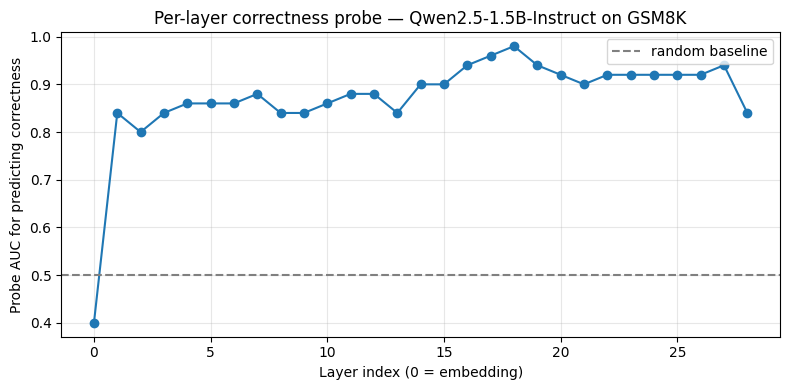

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(per_layer_auc, marker="o")
plt.axhline(0.5, ls="--", color="gray", label="random baseline")
plt.xlabel("Layer index (0 = embedding)")
plt.ylabel("Probe AUC for predicting correctness")
plt.title(f"Per-layer correctness probe — {MODEL_NAME.split('/')[-1]} on GSM8K")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## What to do next

**If this all ran without errors and the AUC plot has a clear peak above 0.5:** the pipeline works. Tell me, paste the AUC numbers, and I'll write the full multi-model multi-dataset version next.

**If the best AUC is around 0.5 across all layers:** something is broken. Most common causes:
- All 50 problems were correct or all were wrong (no class diversity)
- Answer extractor isn't matching the model's output format — look at the Cell 7 examples
- Model is too small to produce stable CoTs

**If you got CUDA out-of-memory:** the Colab T4 ran out of VRAM. Try `MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"` and re-run from Cell 3.

**If everything works but you want more signal:** bump `NUM_SAMPLES` to 200. Will take ~10 minutes.